# Data Analyst portforlio – Ecommerce Retail Analysis
### Oscar Wang

# 0 Business Context and Business Question



## 0-1 Business Context

This dataset comes from a real UK-based online retailer specialising in unique all-occasion gifts, selling exclusively through online channels — no physical storefronts. Its customer base includes both individual shoppers and wholesale buyers, and the company has a full year of transaction history (Dec 2010 – Dec 2011) to draw on.

As the business has grown, customer outreach and product promotion have largely been applied evenly across the customer base. With a full year of data now available, leadership wants a clear, evidence-based view of where value actually comes from before deciding where to focus effort going forward.

## 0-2 Business Question

❓ **Which customers actually drive our revenue, and what specific actions — retention and product recommendations — will protect and grow it?**

## 0-3 Executive Summary

This analysis examines one year of transaction data (541,909 records, ~4,300
customers) from a UK-based online gift retailer. After cleaning the data (removing nulls, duplicates, and cancelled orders), two connected analyses were performed:

- **Customer Segmentation (RFM):** scored each customer on how recently, how often, and how much they purchase, grouping them into six actionable segments — Champions, Loyal Customers, New Customers, At Risk, Lost, and Need Attention.
- **Product Cross-Sell Analysis:** identified which products are most frequently bought together, broken down by segment, to surface concrete bundling opportunities.

💡💡**Headline finding:** Champions and Loyal Customers make up just **37.5%** of customers but generate **77.6%** of revenue — with Champions alone (19.3% of customers) driving 62% on their own.

## 0-4 Summary Business Recommendation

- 📍**Protect:** Champions (19.3% of customers, 62% of revenue) are the single
highest-priority segment — retain first, via loyalty rewards and featuring their signature bundle (Regency Cakestand + Roses Teacup).
- 💪**Grow:** Loyal Customers (18.2%, 15.6%) are the clearest growth opportunity — explicitly package and promote their top pairing (Feltcraft Cushion Owl + Red Floral Shoulder Bag) to nudge them toward Champion-level spend.
- ⏰**Quick win:** At Risk customers (8.8%, 7.2%) offer the highest ROI for a targeted win-back campaign using their known top purchase pattern.
- 🏃**Deprioritise:** Lost customers (30.5% of customers, only 7.6% of revenue) — low-cost automated reactivation only; not worth further investment.

# 1 Data Cleaning and Processing

In [1]:
import pandas as pd

df = pd.read_csv("ecommerce_data.csv", encoding="latin-1")

In [2]:
# First, have an understanding of what dataset looks like
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Understand columns, data types. It contains around 540,000 transactions.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 1-1 Handle Null Values

In [4]:
missing_data = df.isna().sum()
missing_data_percentage = ((missing_data[missing_data>0] / df.shape[0])*100).round(2)
print(missing_data_percentage) # From output, we know only Description and CustomerID have null values

# Remove null values from dataset
df = df.dropna(subset = ['CustomerID', 'Description'])

Description     0.27
CustomerID     24.93
dtype: float64


## 1-2 Remove Duplicates

In [5]:
# Check Duplicated rows first
print('The total rows number is:', df.shape[0])
print('The duplicated rows number is:', df.duplicated().sum())

# Drop the duplicates
df = df.drop_duplicates()
print('The cleaned_dataset total rows number is:', df.shape[0])

The total rows number is: 406829
The duplicated rows number is: 5225
The cleaned_dataset total rows number is: 401604


## 1-3 Remove Cancellations

In [6]:
# Calculate the Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Flag the Cancellation orders
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

print('Total transactions:', df.shape[0])
print('Cancelled transactions:', df['IsCancelled'].sum())
print('Cancelled revenue impact:', df[df['IsCancelled']]['Revenue'].sum())

# Clean the dataset – remove cancellation orders
df_clean = df[~df['IsCancelled']].copy()
print('Remaining transactions for analysis:', df_clean.shape[0])

Total transactions: 401604
Cancelled transactions: 8872
Cancelled revenue impact: -608689.47
Remaining transactions for analysis: 392732


# 2 Data Analysis

## 2-1 Customer Segmentation Analysis

In [7]:
# First, transform InvoiceDate to proper format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Set a reference of a snapshot date – typically one day after the last transaction of the dataset
# This simulates "today" for the business, as if we're analysing the data right after it was collected
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Snapshot date:', snapshot_date)


# Calculate the RFM for per customer
rfm = df_clean.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('Revenue', 'sum')
)
rfm.head(10)

Snapshot date: 2011-12-10 12:50:00


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


| Metric | What it measures | How it's calculated |
|---|---|---|
| **Recency** | How recently a customer purchased | Days between snapshot date and their most recent purchase |
| **Frequency** | How often they purchase | Count of distinct invoices |
| **Monetary** | How much they spend | Sum of revenue across all transactions |


In [8]:
# Score each metric into quintiles (5 equal-sized groups)
# Recency: LOWER is better (recent = good), so scoring is reversed (5 = most recent)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency and Monetary: HIGHER is better, so scoring is normal (5 = highest)
# For Frequency: manually defined, business-interpretable Frequency bins
rfm['F_Score'] = pd.cut(rfm['Frequency'], bins=[0, 1, 2, 4, 8, float('inf')], labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,4,5
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2
12352.0,36,8,2506.04,3,4,5
12353.0,204,1,89.00,1,1,1
12354.0,232,1,1079.40,1,1,4
12355.0,214,1,459.40,1,1,2


In [9]:
def segment_customer(row):
  r = int(row['R_Score'])
  f = int(row['F_Score'])

  if r >= 4 and f >= 4:
    return 'Champions'
  elif r >= 3 and f >= 3:
    return 'Loyal Customers'
  elif r >= 4 and f <= 2:
    return 'New Customers'
  elif r <= 2 and f >= 3:
    return 'At Risk'
  elif r <= 2 and f <= 2:
    return 'Lost'
  else:
    return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,Lost
12347.0,2,7,4310.00,5,4,5,Champions
12348.0,75,4,1797.24,2,3,4,At Risk
12349.0,19,1,1757.55,4,1,4,New Customers
12350.0,310,1,334.40,1,1,2,Lost
12352.0,36,8,2506.04,3,4,5,Loyal Customers
12353.0,204,1,89.00,1,1,1,Lost
12354.0,232,1,1079.40,1,1,4,Lost
12355.0,214,1,459.40,1,1,2,Lost


### 2-2 Segment Profiling

In [10]:
# Profile each segment: size, behaviour, and revenue contribution

segment_profile = rfm.groupby('segment').agg(
    Customer_Count = ('segment', 'count'),
    Avg_Recency = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(1)

# Add the percentage column
segment_profile['% of Customer'] = (segment_profile['Customer_Count'] / segment_profile['Customer_Count'].sum() * 100).round(1)
segment_profile['% of Revenue'] = (segment_profile['Total_Revenue'] / segment_profile['Total_Revenue'].sum() * 100).round(1)

# Reorder by revenue
segment_profile = segment_profile.sort_values('Total_Revenue', ascending=False)
segment_profile

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,% of Customer,% of Revenue
segment,,,,,,,
Champions,837,12.4,12.3,6585.3,5511937.1,19.3,62.0
Loyal Customers,790,33.0,4.3,1751.7,1383857.0,18.2,15.6
Lost,1325,209.6,1.3,510.5,676413.2,30.5,7.6
At Risk,383,137.4,4.4,1670.9,639961.4,8.8,7.2
New Customers,528,17.6,1.5,818.7,432278.1,12.2,4.9
Need Attention,476,53.4,1.4,510.0,242762.0,11.0,2.7


### 2-3 Visualisation

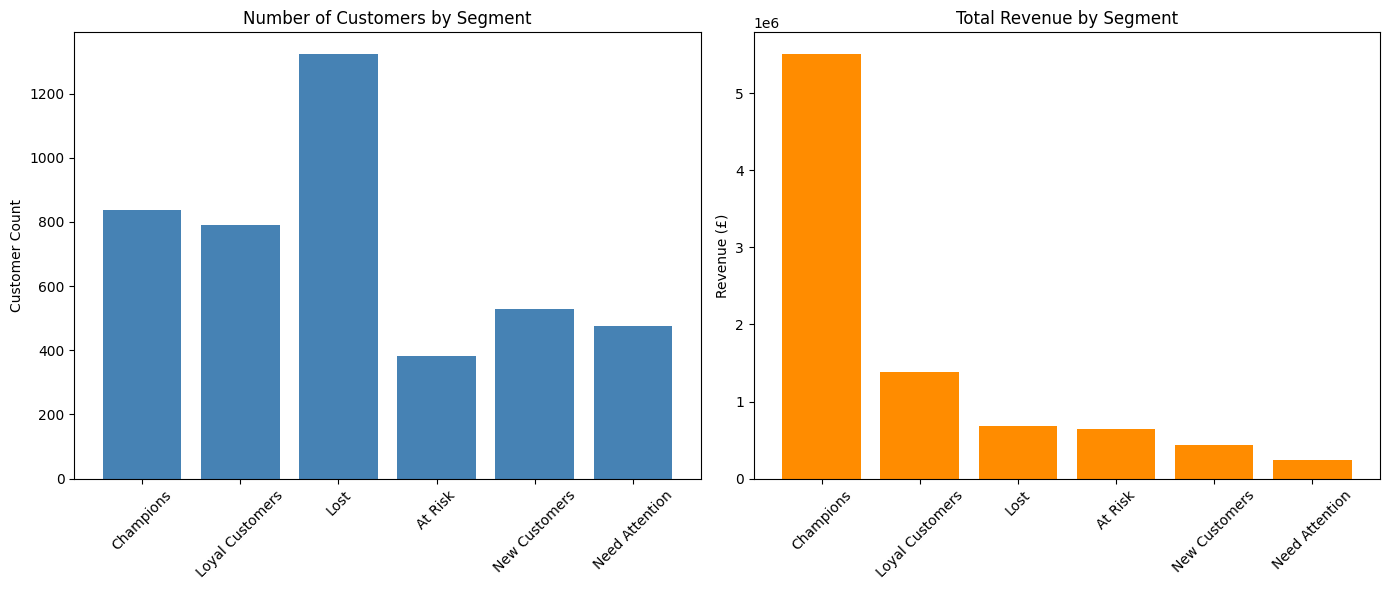

In [11]:
import matplotlib.pyplot as plt

# Set up side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Customer count by segment
axes[0].bar(segment_profile.index, segment_profile['Customer_Count'], color='steelblue')
axes[0].set_title('Number of Customers by Segment')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue contribution by segment
axes[1].bar(segment_profile.index, segment_profile['Total_Revenue'], color='darkorange')
axes[1].set_title('Total Revenue by Segment')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

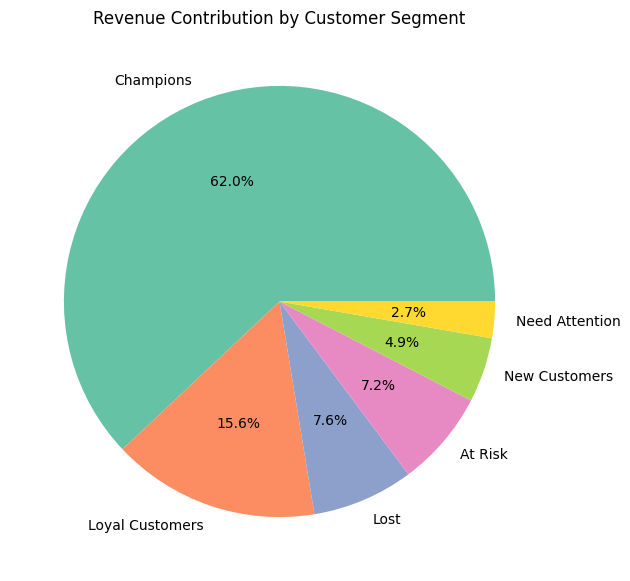

In [12]:
plt.figure(figsize=(7, 7))
plt.pie(segment_profile['Total_Revenue'],
        labels=segment_profile.index,
        autopct='%1.1f%%',
        colors=plt.cm.Set2.colors)
plt.title('Revenue Contribution by Customer Segment')
plt.show()

### 2-4 Business Recommendations


In [13]:
segment_profile.loc['Total'] = segment_profile.sum(axis=0)
segment_profile[['Customer_Count', '% of Customer', '% of Revenue', 'Total_Revenue']]

,Customer_Count,% of Customer,% of Revenue,Total_Revenue
segment,,,,
Champions,837.0,19.3,62.0,5511937.1
Loyal Customers,790.0,18.2,15.6,1383857.0
Lost,1325.0,30.5,7.6,676413.2
At Risk,383.0,8.8,7.2,639961.4
New Customers,528.0,12.2,4.9,432278.1
Need Attention,476.0,11.0,2.7,242762.0
Total,4339.0,100.0,100.0,8887208.8


## 3 Product Cross-Sell Analysis

### 3-1 Looking for Bundles based on Transactions

In [14]:
# Mark the Revenue and cx segmentation on Invoice
df_clean = df_clean.merge(rfm[['segment']], left_on='CustomerID', right_index=True, how='left')

# Transform the transaction-level data to invoice-level data
basket = df_clean.groupby('InvoiceNo').agg(
    Item = ('Description', lambda x: list(x)),
    Revenue = ('Revenue','sum'),
    Segment = ('segment', 'first')).reset_index()
basket.columns = ['Invoice', 'Item', 'Basket_Revenue', 'Segment']

# Keep only multi-item transactions, where single-item transaction has no pairs to find
basket['Item_Count'] = basket['Item'].apply(len)
basket_multi = basket[basket['Item_Count'] > 1].copy()

print(f'Total Invoice:  {basket.shape[0]}')
print(f'Invoice with 2+ Items: {basket_multi.shape[0]}, {round(basket_multi.shape[0] / basket.shape[0]  * 100, 2)}% of the total transactions')

basket_multi.head(10)

Total Invoice:  18536
Invoice with 2+ Items: 17143, 92.48% of the total transactions


,Invoice,Item,Basket_Revenue,Segment,Item_Count
0,536365,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...",139.12,At Risk,7
1,536366,"[HAND WARMER UNION JACK, HAND WARMER RED POLKA...",22.20,At Risk,2
2,536367,"[ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...",278.73,Champions,12
3,536368,"[JAM MAKING SET WITH JARS, RED COAT RACK PARIS...",70.05,Champions,4
5,536370,"[ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",855.86,Champions,20
7,536372,"[HAND WARMER RED POLKA DOT, HAND WARMER UNION ...",22.20,At Risk,2
8,536373,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...",259.86,At Risk,16
10,536375,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...",259.86,At Risk,16
11,536376,"[HOT WATER BOTTLE TEA AND SYMPATHY, RED HANGIN...",328.80,Champions,2
12,536377,"[HAND WARMER RED POLKA DOT, HAND WARMER UNION ...",22.20,At Risk,2


In [15]:
basket_summary = basket_multi.groupby('Segment').agg(
    Basket_Num = ('Invoice', 'count'),
    Segment_Revenue = ('Basket_Revenue', 'sum'))

basket_summary

,Basket_Num,Segment_Revenue
Segment,,
At Risk,1485,571710.841
Champions,9459,5350519.370
Lost,1580,568543.392
Loyal Customers,3203,1318927.111
Need Attention,638,239877.040
New Customers,778,251700.130


### 3-2 Occuring Product Pairs in Different Segments

In [16]:
# Assess each basket product pairs
from itertools import combinations
from collections import Counter

def pair_comparison(df):
    pair_counts = Counter()   # fresh Counters PER GROUP
    pair_revenue = Counter()

    for _, row in df.iterrows():
        unique_items = set(row['Item'])
        for pair in combinations(sorted(unique_items), 2):
            pair_counts[pair] += 1
            pair_revenue[pair] += row['Basket_Revenue']

    # Build and RETURN a DataFrame for this one segment's group
    result = pd.DataFrame(pair_counts.items(), columns=['Pair', 'Count'])
    result['Revenue'] = result['Pair'].map(pair_revenue).round(2)
    return result.sort_values('Revenue', ascending=False)

# apply the function to each segment's group, combine results, keep segment as a label
pairs_by_segment = basket_multi.groupby('Segment').apply(pair_comparison, include_groups=False)
pairs_by_segment.head(10)

Pair  Count  \
Segment                                                                    
At Risk 31731   (GIN + TONIC DIET METAL SIGN, WHITE HANGING HE...     19   
        2533    (GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...     58   
        16607   (FAIRY CAKE FLANNEL ASSORTED COLOUR, WHITE HAN...      5   
        63401   (FAIRY CAKE FLANNEL ASSORTED COLOUR, GIN + TON...      2   
        2550    (REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...     48   
        2532    (GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKE...     44   
        63402          (DOORMAT FAIRY CAKE, TEA TIME TEA TOWELS )      2   
        10522           (PARTY BUNTING, REGENCY CAKESTAND 3 TIER)     36   
        103754  (GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...     46   
        103761  (PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...     45   

                 Revenue  
Segment                   
At Risk 31731   46138.62  
        2533    37948.09  
        16607   37740.17  
        63401   36696.80  
        2550    32863.27  
        2532    30012.59  
        63402   29373.40  
        10522   26269.38  
        103754  26059.29  
        103761  25189.15

Look at the Pair Table, lots of them **share the same product type but colors**, which means a product set rather than a cross-sell bundle. (e.g. Black Towel vs Green Towel) **Filtering the trivial pairs** would benefit insights.

In [17]:
# flag pairs where both items share a common word (likely same product line)
def share_keywords(pair):
  words_a = set(pair[0].split())
  words_b = set(pair[1].split())
  return len(words_a & words_b) >= 2 # 2+ shared words = likely same line
pairs_by_segment['Likely_Same_Line'] = pairs_by_segment['Pair'].apply(share_keywords)
result = pairs_by_segment[~pairs_by_segment['Likely_Same_Line']].sort_values('Revenue', ascending=False).groupby('Segment').head(3)  # genuinely different products bought together


# Tidy up the result table
result = result.merge(basket_summary, left_index=True, right_index=True, how='left').reset_index()
result['% Revenue'] = (result['Revenue']/result['Segment_Revenue']*100).round(2)
result['% Basket'] = (result['Count']/result['Basket_Num']*100).round(2)
# Note: % Revenue and % Basket here are each pair's share within its own segment's basket revenue/count, not of the company total numbers.

result[['Segment', 'Pair', 'Revenue', '% Revenue', '% Basket']]

,Segment,Pair,Revenue,% Revenue,% Basket
0,Champions,"(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...",416519.31,7.78,2.38
1,Champions,"(REGENCY CAKESTAND 3 TIER, SPACEBOY LUNCH BOX )",326997.38,6.11,1.06
2,Champions,"(GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKE...",307258.80,5.74,2.10
3,Loyal Customers,"(FELTCRAFT CUSHION OWL, RED FLORAL FELTCRAFT S...",60003.31,4.55,1.44
4,Loyal Customers,"(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...",57812.04,4.38,2.44
5,Loyal Customers,"(PARTY BUNTING, SPOTTY BUNTING)",53163.68,4.03,2.56
6,At Risk,"(GIN + TONIC DIET METAL SIGN, WHITE HANGING HE...",46138.62,8.07,1.28
7,At Risk,"(FAIRY CAKE FLANNEL ASSORTED COLOUR, WHITE HAN...",37740.17,6.60,0.34
8,At Risk,"(FAIRY CAKE FLANNEL ASSORTED COLOUR, GIN + TON...",36696.80,6.42,0.13
9,Lost,"(JAM MAKING SET WITH JARS, SET OF 3 CAKE TINS ...",30089.51,5.29,2.03


# 4 Business Recommendations

Based on RFM segmentation of 4339 customers (£8,887,209 total revenue) and cross-sell analysis of 17,143 multi-item baskets:

### **Headline finding:** Champions + Loyal Customers make up just **37.5%** of customers but generate **77.6%** of revenue — reinforcing retention-focused spend over broad acquisition.

Note: "Bundle revenue" reflects total basket value for orders containing that pair, not the pair's isolated revenue — used here as a ranking signal, not a direct revenue claim.

---

### 🏆 Champions — 19.3% of customers, 62.0% of revenue
This segment alone justifies the majority of retention investment. Their strongest purchase pattern is **Regency Cakestand 3-Tier + Roses Regency Teacup**, bought together 225 times — the single most reliable combination in the dataset.

**Action:** feature this bundle in VIP/early-access campaigns, and treat it as the benchmark "premium behavior" other segments should be nudged toward. At an average £6,585 spend per customer, retaining even a handful of Champions materially protects revenue — prioritise loyalty rewards and referral incentives here first.

### 💚 Loyal Customers — 18.2% of customers, 15.6% of revenue
The clearest growth lever: large enough to matter, not yet spending like Champions. Their own top pairing — **Feltcraft Cushion Owl + Red Floral Shoulder Bag** — is currently likely bought as two separate line items.

**Action:** package this explicitly as a bundle and promote it directly to this segment; a concrete, testable step toward closing the gap with Champions.

---

### Other segments (brief)
- **Lost (30.5% of customers, 7.6% of revenue):** Largest group by headcount but lowest value — low-cost automated reactivation only; not worth further analysis investment.

- **At Risk (8.8%, 7.2%):** Small but high-ROI to re-engage — target with a "we miss you" email featuring their historical top pair (Gin+Tonic Sign + Heart T-Light Holder).

- **New Customers (12.2%, 4.9%):** Early signal shows interest in the Regency product line — worth surfacing in post-purchase recommendations to drive a second order.

- **Need Attention (11.0%, 2.7%):** Monitor with light-touch newsletters; no dedicated campaign spend justified yet.

# 5 Reference

**Source**

This dataset can be downloaded from https://www.kaggle.com/datasets/carrie1/ecommerce-data/data

The UCI Machine Learning Repository has made this dataset containing actual transactions from 2010 and 2011. The dataset is maintained on their site, where it can be found by the title "Online Retail".

**Acknowledgements**

Per the UCI Machine Learning Repository, this data was made available by Dr Daqing Chen, Director: Public Analytics group. chend '@' lsbu.ac.uk, School of Engineering, London South Bank University, London SE1 0AA, UK.

